In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from xgboost import XGBClassifier, XGBRegressor

from tensorflow.keras.models import load_model

In [12]:
df = pd.read_csv(r"D:\BE\BE\BE 8th Sem\Internship\Evostra Major Project\evoastra-capstone\evoastra-capstone\data\processed\DataCoSupplyChain_clean.csv")

print(df.shape)
df.head()

(124993, 57)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,shipping_mode,order_year,order_month,order_day,order_weekday,is_weekend,shipping_delay,profit_margin,sales_per_item,order_size
0,1,3,4,91.250000,314.640015,0,0,73,36,66,...,3,2018,1,31,2,0,-1,0.278413,327.75,327.75
1,3,5,4,-249.089996,311.359985,1,1,73,36,66,...,3,2018,1,13,5,1,1,-0.760000,327.75,327.75
2,0,4,4,-247.779999,309.720001,3,0,73,36,452,...,3,2018,1,13,5,1,0,-0.756003,327.75,327.75
3,1,3,4,22.860001,304.809998,0,0,73,36,285,...,3,2018,1,13,5,1,-1,0.069748,327.75,327.75
4,2,2,4,134.210007,298.250000,0,0,73,36,66,...,3,2018,1,13,5,1,-2,0.409489,327.75,327.75


In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, ":", df[col].nunique())

order_date_dateorders : 53307
shipping_date_dateorders : 51939


In [14]:
df = df.drop([
    "order_date_dateorders",
    "shipping_date_dateorders",
    "customer_street",
    "product_description",
    "product_name"
], axis=1, errors="ignore")

In [15]:
categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols)

Index([], dtype='object')


In [16]:
X = df.drop(["late_delivery_risk", "sales"], axis=1)

y_risk = df["late_delivery_risk"]
y_sales = df["sales"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_risk_train, y_risk_test, y_sales_train, y_sales_test = train_test_split(
    X, y_risk, y_sales,
    test_size=0.2,
    random_state=42
)

In [18]:
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (99994, 50)
Testing size: (24999, 50)


In [19]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Random Forest for late delivery risk (classification)
rf_risk = RandomForestClassifier(n_estimators=100, random_state=42)
rf_risk.fit(X_train, y_risk_train)

# Random Forest for sales prediction (regression)
rf_sales = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sales.fit(X_train, y_sales_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
rf_risk_pred = rf_risk.predict(X_test)
rf_sales_pred = rf_sales.predict(X_test)

In [21]:
from xgboost import XGBClassifier, XGBRegressor

# XGBoost for late delivery risk (classification)
xgb_risk = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb_risk.fit(X_train, y_risk_train)


# XGBoost for sales prediction (regression)
xgb_sales = XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_sales.fit(X_train, y_sales_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential()

nn_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
nn_model.add(Dense(32, activation='relu'))

# output layer for risk prediction
nn_model.add(Dense(1, activation='sigmoid'))

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.fit(
    X_train,
    y_risk_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

c:\Users\Sony\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.5153 - loss: 118.8221 - val_accuracy: 0.5260 - val_loss: 35.5077
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5294 - loss: 60.6508 - val_accuracy: 0.5653 - val_loss: 38.0159
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5469 - loss: 40.5810 - val_accuracy: 0.5572 - val_loss: 47.1418
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5667 - loss: 27.6856 - val_accuracy: 0.5495 - val_loss: 22.6185
Epoch 5/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5919 - loss: 19.9945 - val_accuracy: 0.5821 - val_loss: 14.1255


In [23]:
nn_risk_pred = (nn_model.predict(X_test) > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [24]:
xgb_risk_pred = xgb_risk.predict(X_test)
xgb_sales_pred = xgb_sales.predict(X_test)

In [25]:
results = X_test.copy()

results["actual_risk"] = y_risk_test

results["rf_risk"] = rf_risk_pred
results["xgb_risk"] = xgb_risk_pred
results["nn_risk"] = nn_risk_pred

In [26]:
print("order_region" in results.columns)

True


In [27]:
risk_bias = results.groupby("order_region")[["rf_risk","xgb_risk","nn_risk"]].mean()

print(risk_bias)

               rf_risk  xgb_risk   nn_risk
order_region                              
0             0.436508  0.436508  0.984127
1             0.540833  0.540833  0.981667
2             0.580913  0.580913  0.995851
3             0.552833  0.552833  0.979461
4             0.544444  0.544444  0.966667
5             0.611111  0.611111  0.984127
6             0.576098  0.576098  0.969356
7             0.565733  0.565733  0.933190
8             0.550088  0.550088  0.992970
9             0.527840  0.527840  0.975501
10            0.544792  0.544792  0.975237
11            0.575158  0.575158  0.942247
12            0.540890  0.540890  0.973697
13            0.595833  0.595833  0.970833
14            0.544280  0.544280  0.961255
15            0.584921  0.584921  0.945319
16            0.534161  0.534161  0.962733
17            0.566987  0.566987  0.966691
18            0.596556  0.596556  0.971710
19            0.524366  0.524366  0.974659
20            0.579202  0.579202  0.987908
21         

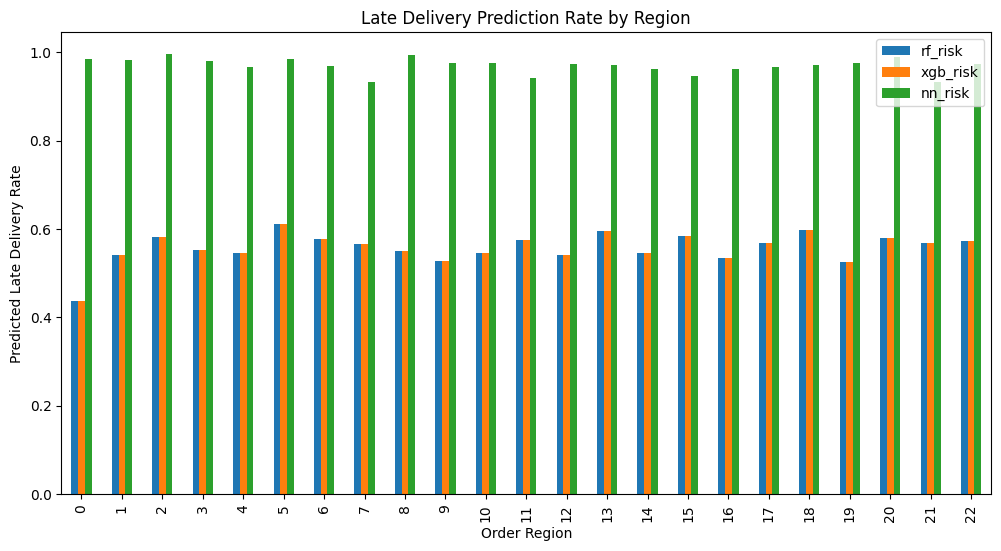

In [28]:
import matplotlib.pyplot as plt

risk_bias.plot(kind="bar", figsize=(12,6))

plt.title("Late Delivery Prediction Rate by Region")
plt.ylabel("Predicted Late Delivery Rate")
plt.xlabel("Order Region")

plt.show()

In [29]:
from sklearn.metrics import accuracy_score

accuracy_by_region = results.groupby("order_region").apply(
    lambda x: accuracy_score(x["actual_risk"], x["rf_risk"])
)

print(accuracy_by_region)

order_region
0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
dtype: float64


C:\Users\Sony\AppData\Local\Temp\ipykernel_8096\2331649013.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  accuracy_by_region = results.groupby("order_region").apply(


### Fairlearn metrics

In [30]:
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import demographic_parity_difference
from fairlearn.metrics import equalized_odds_difference

In [31]:
dp = demographic_parity_difference(
    y_true=y_risk_test,
    y_pred=rf_risk_pred,
    sensitive_features=results["order_region"]
)

eo = equalized_odds_difference(
    y_true=y_risk_test,
    y_pred=rf_risk_pred,
    sensitive_features=results["order_region"]
)

print("Demographic Parity Difference:", dp)
print("Equal Opportunity Difference:", eo)

Demographic Parity Difference: 0.17460317460317465
Equal Opportunity Difference: 0.0


Meaning of the Metrics
Demographic Parity Difference (DP): Measures whether prediction rates are equal across groups (regions in your case).


Equal Opportunity Difference (EO) :

Measures whether true positive rates are equal across groups.
